In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [2]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph.message import add_messages

# 상태 정의
class State(TypedDict):	
    messages: Annotated[list[str], add_messages]

In [3]:
from langgraph.graph import StateGraph

# 그래프 구성
graph_builder = StateGraph(State)

In [4]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """
    특정 지역의 현재 시각을 반환하는 함수.
    
    Args:
        timezone (str): pytz 타임존 형식의 문자열 (예: 'Asia/Seoul', 'America/New_York', 'Europe/London')
                       한국의 경우 'Asia/Seoul'을 사용합니다.
        location (str): 사용자가 질문한 도시나 지역 이름 (예: '서울', '부산', '뉴욕')
    
    Returns:
        str: 해당 지역의 현재 시각 정보
    
    Examples:
        - 부산의 현재 시각: timezone='Asia/Seoul', location='부산'
        - 서울의 현재 시각: timezone='Asia/Seoul', location='서울'
        - 뉴욕의 현재 시각: timezone='America/New_York', location='뉴욕'
    """
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재시각 {now}'
        # print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"
    
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색할 키워드나 질문
        search_period (str): 검색 기간 설정 (기본값: 'm')
                            - 'd': 최근 하루 (day)
                            - 'w': 최근 일주일 (week)
                            - 'm': 최근 한 달 (month)
                            - 'y': 최근 일 년 (year)

    Returns:
        str: 검색 결과 문자열

    Examples:
        - **최신 이슈 검색:** query='오늘의 경제 뉴스', search_period='d' 
          (특정 시점의 최신 정보를 찾는 경우)
        - **일반 기술 자료 검색:** query='Python 튜토리얼', search_period='m'
          (최근의 일반적인 자료를 찾는 경우)
        - **역사/배경 자료 검색:** query='르네상스 시대의 주요 화가', search_period='y'
          (광범위한 기간의 자료를 찾는 경우)
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region="kr-kr", 
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_current_time, get_web_search]

In [5]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "부산"})

'Asia/Seoul (부산) 현재시각 2025-12-08 16:09:53'

In [34]:
query = "쿠팡 개인정보 유출 사건의 원인은?"

In [35]:
tools[1].invoke({"query": query, "search_period": "m"})


-------- WEB SEARCH --------
쿠팡 개인정보 유출 사건의 원인은?
m
1. snippet: 쿠팡 개인정보 유출 사건의 전말과 유출 경로. 2025년 11월 중순, 쿠팡에서 대규모 개인정보 유출 사고가 발생했다는 사실이 알려지면서 많은 이용자들이 충격에 빠졌습니다., title: 쿠팡 개인정보 유출 경로 규모 과태료 주식 영향 | 달콤블, link: https://dal.ydpn.kr/쿠팡-개인정보-유출-경로-규모-과태료-주식-영향/
2. snippet: 이 사건의 원인은 내부자(중국 국적 전 직원)로 지목되었으며, 퇴사 후 폐기되지 않은 토큰이 악용된 점이 문제시되었습니다.Q3: 쿠팡 개인정보 유출 시 내 정보는 안전한가요?, title: 쿠팡 로그인 기록 확인 및 실시간 개인정보 누출 조회, link: https://info.yiwi.co.kr/쿠팡-로그인-기록-확인/
3. snippet: LIVE ISSUE 쿠팡 고객정보 유출 사고. 쿠팡 개인정보 유출 사태로 논란이 이어지는 4일 서울 시내 한 쿠팡 물류센터에 배송 차량이 주차돼 있다., title: 경찰 " 쿠팡 개인정보 유출 , 보이스피싱 등 2차 피해 확인 안 돼" | 한국일보, link: https://www.hankookilbo.com/News/Read/A2025120515070003794
4. snippet: 실제로 2025년 통계에 따르면, 개인정보 유출 사건의 65%가 사용자 부주의에서 발생하고 있습니다., title: 쿠팡 개인정보 유출 내 계정 로그인 기록 조회, link: https://avenue34.co.kr/coupang-personal-information/


'snippet: 쿠팡 개인정보 유출 사건의 전말과 유출 경로. 2025년 11월 중순, 쿠팡에서 대규모 개인정보 유출 사고가 발생했다는 사실이 알려지면서 많은 이용자들이 충격에 빠졌습니다., title: 쿠팡 개인정보 유출 경로 규모 과태료 주식 영향 | 달콤블, link: https://dal.ydpn.kr/쿠팡-개인정보-유출-경로-규모-과태료-주식-영향/;\nsnippet: 이 사건의 원인은 내부자(중국 국적 전 직원)로 지목되었으며, 퇴사 후 폐기되지 않은 토큰이 악용된 점이 문제시되었습니다.Q3: 쿠팡 개인정보 유출 시 내 정보는 안전한가요?, title: 쿠팡 로그인 기록 확인 및 실시간 개인정보 누출 조회, link: https://info.yiwi.co.kr/쿠팡-로그인-기록-확인/;\nsnippet: LIVE ISSUE 쿠팡 고객정보 유출 사고. 쿠팡 개인정보 유출 사태로 논란이 이어지는 4일 서울 시내 한 쿠팡 물류센터에 배송 차량이 주차돼 있다., title: 경찰 " 쿠팡 개인정보 유출 , 보이스피싱 등 2차 피해 확인 안 돼" | 한국일보, link: https://www.hankookilbo.com/News/Read/A2025120515070003794;\nsnippet: 실제로 2025년 통계에 따르면, 개인정보 유출 사건의 65%가 사용자 부주의에서 발생하고 있습니다., title: 쿠팡 개인정보 유출 내 계정 로그인 기록 조회, link: https://avenue34.co.kr/coupang-personal-information/'

In [8]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description="특정 지역의 현재 시각을 반환하는 함수.\n\nArgs:\n    timezone (str): pytz 타임존 형식의 문자열 (예: 'Asia/Seoul', 'America/New_York', 'Europe/London')\n                   한국의 경우 'Asia/Seoul'을 사용합니다.\n    location (str): 사용자가 질문한 도시나 지역 이름 (예: '서울', '부산', '뉴욕')\n\nReturns:\n    str: 해당 지역의 현재 시각 정보\n\nExamples:\n    - 부산의 현재 시각: timezone='Asia/Seoul', location='부산'\n    - 서울의 현재 시각: timezone='Asia/Seoul', location='서울'\n    - 뉴욕의 현재 시각: timezone='America/New_York', location='뉴욕'" args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x0000027F044C5A80>
get_web_search name='get_web_search' description="웹 검색을 수행하는 함수.\n\nArgs:\n    query (str): 검색할 키워드나 질문\n    search_period (str): 검색 기간 설정 (기본값: 'm')\n                        - 'd': 최근 하루 (day)\n                        - 'w': 최근 일주일 (week)\n                        - 'm': 최근 한 달 (month)\n                        - 'y': 최근 일 년 (year)\n\nReturns:\n    str: 검색 결과 문자열

In [9]:
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결

def generate(state: State):
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [10]:
tools

[StructuredTool(name='get_current_time', description="특정 지역의 현재 시각을 반환하는 함수.\n\nArgs:\n    timezone (str): pytz 타임존 형식의 문자열 (예: 'Asia/Seoul', 'America/New_York', 'Europe/London')\n                   한국의 경우 'Asia/Seoul'을 사용합니다.\n    location (str): 사용자가 질문한 도시나 지역 이름 (예: '서울', '부산', '뉴욕')\n\nReturns:\n    str: 해당 지역의 현재 시각 정보\n\nExamples:\n    - 부산의 현재 시각: timezone='Asia/Seoul', location='부산'\n    - 서울의 현재 시각: timezone='Asia/Seoul', location='서울'\n    - 뉴욕의 현재 시각: timezone='America/New_York', location='뉴욕'", args_schema=<class 'langchain_core.utils.pydantic.get_current_time'>, func=<function get_current_time at 0x0000027F044C5A80>),
 StructuredTool(name='get_web_search', description="웹 검색을 수행하는 함수.\n\nArgs:\n    query (str): 검색할 키워드나 질문\n    search_period (str): 검색 기간 설정 (기본값: 'm')\n                        - 'd': 최근 하루 (day)\n                        - 'w': 최근 일주일 (week)\n                        - 'm': 최근 한 달 (month)\n                        - 'y': 최근 일 년 (year)\n\nReturns:\n    str: 검색 

In [11]:
from pprint import pprint

# * 딕셔너리 컴프리헨션(Dictionary Comprehension)
# - 키(Key): tool.name은 현재 순회 중인 StructuredTool 객체의 name 속성 값을 추출하여 딕셔너리의 키로 사용한다.
# - 값(Value): tool은 현재 순회 중인 StructuredTool 객체 자체를 딕셔너리의 값으로 사용한다.
pprint({tool.name: tool for tool in tools})

{'get_current_time': StructuredTool(name='get_current_time', description="특정 지역의 현재 시각을 반환하는 함수.\n\nArgs:\n    timezone (str): pytz 타임존 형식의 문자열 (예: 'Asia/Seoul', 'America/New_York', 'Europe/London')\n                   한국의 경우 'Asia/Seoul'을 사용합니다.\n    location (str): 사용자가 질문한 도시나 지역 이름 (예: '서울', '부산', '뉴욕')\n\nReturns:\n    str: 해당 지역의 현재 시각 정보\n\nExamples:\n    - 부산의 현재 시각: timezone='Asia/Seoul', location='부산'\n    - 서울의 현재 시각: timezone='Asia/Seoul', location='서울'\n    - 뉴욕의 현재 시각: timezone='America/New_York', location='뉴욕'", args_schema=<class 'langchain_core.utils.pydantic.get_current_time'>, func=<function get_current_time at 0x0000027F044C5A80>),
 'get_web_search': StructuredTool(name='get_web_search', description="웹 검색을 수행하는 함수.\n\nArgs:\n    query (str): 검색할 키워드나 질문\n    search_period (str): 검색 기간 설정 (기본값: 'm')\n                        - 'd': 최근 하루 (day)\n                        - 'w': 최근 일주일 (week)\n                        - 'm': 최근 한 달 (month)\n                        - 'y': 최

In [12]:
# * 왈러스(walrus) 연산자
# - 바다코끼리 닮아서 붙여진 이름
# - Python 3.8부터 도입된 문법
# - 일반적인 할당 연산자 (=)가 문(statement)인 반면, 왈러스 연산자는 식(expression)
# - 변수에 값을 할당하면서 동시에 그 값에 대한 참/거짓을 판별
dic = {"messages": ["a", "b"]}
if var := dic.get("messages"):
    print(var)

['a', 'b']


In [13]:
# import json
# from langchain_core.messages import ToolMessage

# class BasicToolNode:
#     """
#     도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
#     """

#     def __init__(self, tools: list) -> None:
#         self.tools_by_name = {tool.name: tool for tool in tools} # 딕셔너리 컴프리헨션(Dictionary Comprehension)

#     def __call__(self, inputs: dict):
#         # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트를 가져옵니다.
#         if messages := inputs.get("messages", []): # 왈러스(walrus) 연산자 사용
#             message = messages[-1]
#         else:
#             raise ValueError("No message found in input")
#         outputs = []
#         for tool_call in message.tool_calls:
#             tool_result = self.tools_by_name[tool_call["name"]].invoke(
#                 tool_call["args"]
#             )
#             outputs.append(
#                 ToolMessage(
#                     content=json.dumps(tool_result),
#                     name=tool_call["name"],
#                     tool_call_id=tool_call["id"],
#                 )
#             )
#         return {"messages": messages + outputs}

In [14]:
# # * Case1
# tool_node = BasicToolNode(tools=tools)
# graph_builder.add_node("tools", tool_node)

In [15]:
# * Case2
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [16]:
from langgraph.graph import START, END

def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 END로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
        
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [17]:
graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "generate")

In [18]:
graph = graph_builder.compile()

In [19]:
# # [venv 경로]\Lib\site-packages\langchain_core\runnables\graph_mermaid.py
# # 파일을 열고 `_render_mermaid_using_pyppeteer` 함수 내부에 있는 `pyppeteer.launch()` 호출 부분을 찾아 `executablePath` 인자를 추가한다.
# # browser = await launch(executablePath=r'C:\Program Files\Google\Chrome\Application\chrome.exe')
# import nest_asyncio
# from IPython.display import display, Image
# from langchain_core.runnables.graph_mermaid import MermaidDrawMethod

# # nest_asyncio를 적용하여 이벤트 루프 중첩 오류를 해결한다.
# nest_asyncio.apply()

# # (옵션) 그래프를 시각화
# # 이 코드는 이미 langchain_core 라이브러리의 pyppeteer.launch()에 
# # executablePath가 하드코딩된 상태를 전제로 한다.
# display(Image(graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))

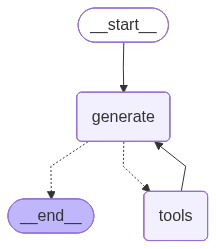

In [20]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [21]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 부산 몇시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

부산은 현재 2025년 12월 8일 16시 9분 56초입니다.

In [22]:
gathered

AIMessageChunk(content='부산은 현재 2025년 12월 8일 16시 9분 56초입니다.', additional_kwargs={'function_call': {'name': 'get_current_time', 'arguments': '{"location": "\\ubd80\\uc0b0", "timezone": "Asia/Seoul"}'}}, response_metadata={'finish_reason': 'STOPSTOP', 'model_name': 'gemini-2.5-flash-litegemini-2.5-flash-lite', 'safety_ratings': []}, id='run--5dbba7c4-73a3-4018-89a7-b4397f32db42', tool_calls=[{'name': 'get_current_time', 'args': {'location': '부산', 'timezone': 'Asia/Seoul'}, 'id': '12bc70f1-64ca-478c-a030-0eedf20ac844', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1073, 'output_tokens': 53, 'total_tokens': 1126, 'input_token_details': {'cache_read': 0}}, tool_call_chunks=[{'name': 'get_current_time', 'args': '{"location": "\\ubd80\\uc0b0", "timezone": "Asia/Seoul"}', 'id': '12bc70f1-64ca-478c-a030-0eedf20ac844', 'index': None, 'type': 'tool_call_chunk'}])

In [41]:
query

'쿠팡 개인정보 유출 사건의 원인은?'

In [42]:
from langchain_core.messages import AIMessageChunk, SystemMessage

inputs = [
    SystemMessage(content=f"""
        너는 신문기자이다. 
        최근 {query}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.
    """),
    HumanMessage(content="""
        - 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘. 
        - 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐. 
        - 검색할 리스트를 토대로 재검색을 한다. 
        - 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
        - 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다. 
        
        더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성하라.
        제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다.
    """)
]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg


-------- WEB SEARCH --------
최근 주요 이슈
d
1. snippet: Samil PwC Insights Issue Brief 대기업 Carve-out Deal의 주요 이슈 및 향후 전망. 최근 5년간 국내 주요 Carve-out Deal 사례. 매수인: 고금리 시대, 안정성을 추구., title: 대기업 Carve-out Deal의 주요 이슈 및 향후 전망 : 삼일회계법인, link: https://www.pwc.com/kr/ko/insights/issue-brief/carve-out-deal.html
2. snippet: Executive Summary. 새로운 규제의 필요성. 과거 이슈 모니터링.바젤 III, 최근 흐름의 변화., title: 바젤 III 도입 배경 및 최근 주요 이슈들 - KPMG 한국, link: https://kpmg.com/kr/ko/home/insights/2015/03/issue-monitor-_33--iii------.html
3. snippet: 삼성전자 주가 현황 및 최근 주요 이슈 분석., title: 삼성전자 주가분석 리포트(25.12.07.) : HBM과 D램 1위 탈환, 반도체..., link: https://eduinfom.com/삼성전자-주가분석-리포트25-12-07-hbm과-d램-1위-탈환-반도체/
4. snippet: Okta의 주요 제품과 서비스. Okta의 수익 구조. Okta의 경쟁 우위. 최근 주요 이슈 . Okta의 투자 전망. 배당 정보., title: 옥타 (OKTA) 기업 분석, 소개, 주요 이슈 , 주가 전망, 기술 분석 - Glocal..., link: https://secondmin.co.kr/okta-company-analysis/
        최근 가장 큰 관심을 받고 있는 이슈는 단연 '쿠팡 개인정보 유출 사건'입니다. 이 사건은 단순히 기업의 보안 문제를 넘어, 소비자들이 안심하고 온라인 쇼핑을 즐길 수 있는 환경에 대한 근본적인 질문을 던지고 있습니다. 따

In [43]:
gathered

AIMessageChunk(content="        최근 가장 큰 관심을 받고 있는 이슈는 단연 '쿠팡 개인정보 유출 사건'입니다. 이 사건은 단순히 기업의 보안 문제를 넘어, 소비자들이 안심하고 온라인 쇼핑을 즐길 수 있는 환경에 대한 근본적인 질문을 던지고 있습니다. 따라서 저는 이 사건을 심층적으로 분석하여 쿠팡의 책임과 재발 방지 대책을 집중적으로 다루고자 합니다.\n\n## 쿠팡 개인정보 유출 사건 심층 분석 기사 목차\n\n**1. 서론: 쿠팡 개인정보 유출, 무엇이 문제인가?**\n    * 사건 개요 및 피해 규모\n    * 개인정보 유출이 소비자에게 미치는 영향\n\n**2. 쿠팡 개인정보 유출의 원인 분석**\n    * 기술적 보안 취약점 (해킹 경로, 시스템 오류 등)\n    * 관리적 보안 시스템의 허점 (내부 통제, 직원 관리 등)\n    * 쿠팡의 보안 투자 및 대응 현황\n\n**3. 개인정보 보호법 위반 및 법적 책임**\n    * 현행 개인정보 보호법 상 쿠팡의 의무\n    * 법 위반 시 예상되는 법적 제재 및 과징금\n    * 유사 사건 판례 및 법적 쟁점\n\n**4. 쿠팡의 책임과 향후 과제**\n    * 피해 보상 및 재발 방지 대책\n    * 소비자의 권리 보호 방안\n    * 국내 이커머스 시장의 개인정보 보호 현황 진단\n\n**5. 결론: 신뢰 회복을 위한 쿠팡의 노력과 제언**\n    * 쿠팡의 진정성 있는 사과와 실질적인 조치 촉구\n    * 정부 및 관련 기관의 감독 강화 필요성\n    * 소비자의 현명한 대처 방안\n\n## 목차 완성을 위한 추가 검색 리스트\n\n*   쿠팡 개인정보 유출 사건 상세 경위 (언론 보도 종합)\n*   쿠팡 해킹 경로 및 방법 (기술적 분석)\n*   쿠팡 내부 보안 시스템 현황 및 문제점\n*   개인정보 유출 시 쿠팡의 대응 절차 및 효과\n*   개인정보 보호법 개정안 및 강화 동향\n*   쿠팡 개인정보 유출 관련 소비자 피해 사례\n* 

In [44]:
print(gathered.content)

        최근 가장 큰 관심을 받고 있는 이슈는 단연 '쿠팡 개인정보 유출 사건'입니다. 이 사건은 단순히 기업의 보안 문제를 넘어, 소비자들이 안심하고 온라인 쇼핑을 즐길 수 있는 환경에 대한 근본적인 질문을 던지고 있습니다. 따라서 저는 이 사건을 심층적으로 분석하여 쿠팡의 책임과 재발 방지 대책을 집중적으로 다루고자 합니다.

## 쿠팡 개인정보 유출 사건 심층 분석 기사 목차

**1. 서론: 쿠팡 개인정보 유출, 무엇이 문제인가?**
    * 사건 개요 및 피해 규모
    * 개인정보 유출이 소비자에게 미치는 영향

**2. 쿠팡 개인정보 유출의 원인 분석**
    * 기술적 보안 취약점 (해킹 경로, 시스템 오류 등)
    * 관리적 보안 시스템의 허점 (내부 통제, 직원 관리 등)
    * 쿠팡의 보안 투자 및 대응 현황

**3. 개인정보 보호법 위반 및 법적 책임**
    * 현행 개인정보 보호법 상 쿠팡의 의무
    * 법 위반 시 예상되는 법적 제재 및 과징금
    * 유사 사건 판례 및 법적 쟁점

**4. 쿠팡의 책임과 향후 과제**
    * 피해 보상 및 재발 방지 대책
    * 소비자의 권리 보호 방안
    * 국내 이커머스 시장의 개인정보 보호 현황 진단

**5. 결론: 신뢰 회복을 위한 쿠팡의 노력과 제언**
    * 쿠팡의 진정성 있는 사과와 실질적인 조치 촉구
    * 정부 및 관련 기관의 감독 강화 필요성
    * 소비자의 현명한 대처 방안

## 목차 완성을 위한 추가 검색 리스트

*   쿠팡 개인정보 유출 사건 상세 경위 (언론 보도 종합)
*   쿠팡 해킹 경로 및 방법 (기술적 분석)
*   쿠팡 내부 보안 시스템 현황 및 문제점
*   개인정보 유출 시 쿠팡의 대응 절차 및 효과
*   개인정보 보호법 개정안 및 강화 동향
*   쿠팡 개인정보 유출 관련 소비자 피해 사례
*   다른 이커머스 업체의 개인정보 보호 시스템 비교

## 쿠팡 개인정보 유출 사건: '안전 제일'이라는 허